# **Credit Card Fraud Projection**

The machine learning techniques used in the project were Logistic Regression and Classification (Decision Tree). The coding for each techniques is detailed below.

## Machine Learning Technique 1: Logistic Regression



In [9]:
# import dataset:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/MSDA 665/fraud test.v3.csv")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# import all necessary packages
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np

In [17]:
# confirm the dataset was imported properly, get dataset info:
df.describe()
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   count                  1499 non-null   int64  
 1   trans_date_trans_time  1499 non-null   object 
 2   cc_num                 1499 non-null   float64
 3   merchant               1499 non-null   object 
 4   category               1499 non-null   object 
 5   amt                    1499 non-null   float64
 6   first                  1499 non-null   object 
 7   last                   1499 non-null   object 
 8   gender                 1499 non-null   object 
 9   street                 1499 non-null   object 
 10  city                   1499 non-null   object 
 11  state                  1499 non-null   object 
 12  zip                    1499 non-null   int64  
 13  lat                    1499 non-null   float64
 14  long                   1499 non-null   float64
 15  city

,count,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,time_actual,merch_lat,merch_long,is_fraud
0,0,21/06/2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,-80.9355,333497,Mechanical engineer,19/03/1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,12:14:25 PM,33.986391,-81.200714,0
1,1,21/06/2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,-110.4360,302,"Sales professional, IT",17/01/1990,324cc204407e99f51b0d6ca0055005e7,1371816873,12:14:33 PM,39.450498,-109.960431,0
2,2,21/06/2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,-73.5365,34496,"Librarian, public",21/10/1970,c81755dbbbea9d5c77f094348a7579be,1371816893,12:14:53 PM,40.495810,-74.196111,0
3,3,21/06/2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,-80.8191,54767,Set designer,25/07/1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,12:15:15 PM,28.812398,-80.883061,0
4,4,21/06/2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,-85.0170,1126,Furniture designer,6/7/1955,57ff021bd3f328f8738bb535c302a31b,1371816917,12:15:17 PM,44.959148,-85.884734,0


In [18]:
# specifying x + y variables of interest:

X = df[['category', 'gender', 'amt', 'job', 'city_pop', 'city']]
y = df['is_fraud']

# convert categorical variables to numerical
X = pd.get_dummies(data = X, drop_first = True)

display(X.head())

,amt,city_pop,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,...,city_Williamsburg,city_Wilmette,city_Wilmington,city_Wilton,city_Winger,city_Winthrop,city_Wittenberg,city_Woodville,city_Yellowstone National Park,city_Zavalla
0,2.86,333497,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,29.84,302,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,41.28,34496,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,60.05,54767,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3.19,1126,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# training the dataset: 80% vs. 20% spilt
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 750)

Text(0.5, 427.9555555555555, 'Predicted label')

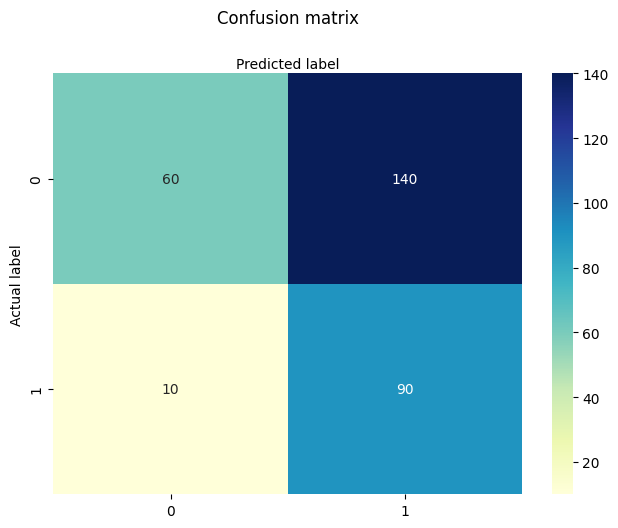

In [22]:
# creating confusion matrix
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot = True, cmap = "YlGnBu" ,fmt = 'g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y = 1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [23]:
# generate classification report
df_target_names = ['Fraud-No', 'Fraud-Yes']
print(classification_report(y_test, y_pred, target_names = df_target_names))

              precision    recall  f1-score   support

    Fraud-No       0.86      0.30      0.44       200
   Fraud-Yes       0.39      0.90      0.55       100

    accuracy                           0.50       300
   macro avg       0.62      0.60      0.49       300
weighted avg       0.70      0.50      0.48       300



## Machine Learning Technique 2: Decision Tree



In [30]:
# training the dataset: 80% vs. 20% spilt
from sklearn.tree import DecisionTreeClassifier

# specifying x + y variables of interest:
X = df[['category', 'gender', 'amt', 'job', 'city_pop', 'city']]
y = df['is_fraud']


# convert categorical variables to numerical
X = pd.get_dummies(data = X, drop_first = True)

display(X.head())

,amt,city_pop,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,...,city_Williamsburg,city_Wilmette,city_Wilmington,city_Wilton,city_Winger,city_Winthrop,city_Wittenberg,city_Woodville,city_Yellowstone National Park,city_Zavalla
0,2.86,333497,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,29.84,302,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,41.28,34496,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,60.05,54767,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3.19,1126,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
# training the dataset: 80% vs. 20% spilt
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 500)

In [37]:
# use the train data set to build the decision tree classifier clf (max_depth = 3) and predict the value of Y for the test set
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

clf = clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

Text(0.5, 427.9555555555555, 'Predicted label')

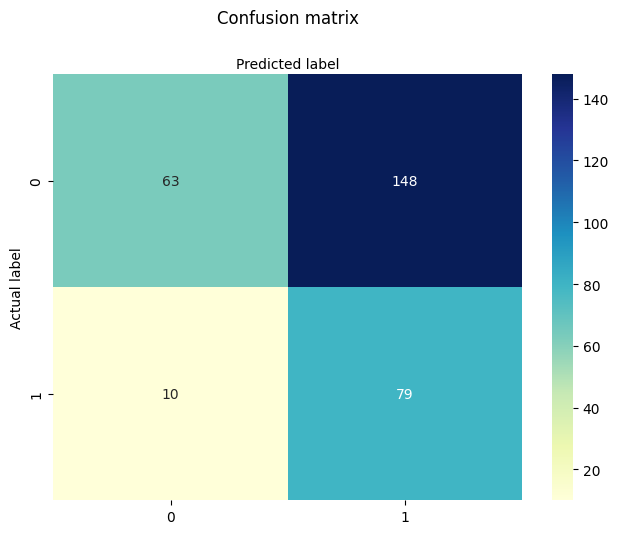

In [38]:
# creating confusion matrix
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot = True, cmap = "YlGnBu" ,fmt = 'g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y = 1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

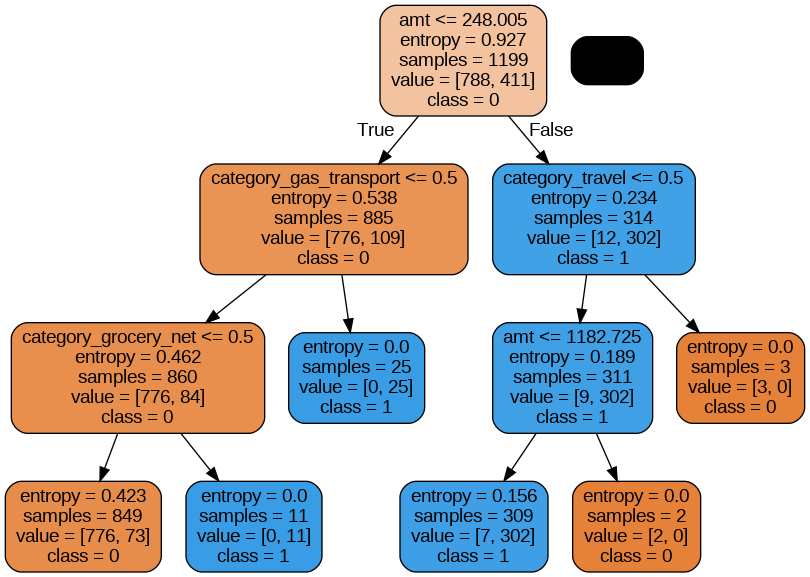

In [39]:
# create decision tree
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus
feature_cols = X.columns
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
            filled=True, rounded=True,
            feature_names = feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('Fraud.png')
Image(graph.create_png())
